# Three-class Pointwise MLP · 17 presynaptic embeddings + post · 5 folds

Classes: BasketFam; nonBasketInhibitory (BipFam, MartFam, NglFam); Excitatory (pyramidal, thalamocortical). Same original folds 0–4 and pre + post inputs. These are new trainings with a three-output classifier, using the original 30 epochs and hyperparameters. Fold means weight folds equally; standard deviation uses ddof=1. Validation and testing share the original held-out split. Run all cells once completed fold results are available.


Running folds appear with best-so-far metrics. Completed-fold aggregates exclude unfinished runs. Outputs are a saved snapshot; use Run All to refresh.

In [1]:
%matplotlib inline
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / 'scripts/train_gnn.py').is_file())
RESULT_ROOT = ROOT / 'results/presynaptic/native_skeletons_pre_post/scale16/k17/conf0.7/three_class'
RUN = 'gnn_lcpn_scratch_pointwise_mlp_L2_resnet4x128_n17_mixed16_sampled_pre_post'
MODEL = 'Pointwise MLP · 17 presynaptic embeddings + post · 5 folds'
FOLDS = range(5)
COLORS = plt.get_cmap('tab10').colors[:5]
pd.options.display.float_format = '{:.4f}'.format


## Fold status and best-checkpoint performance

Each fold shows its latest recorded epoch and whether final results are available. Running folds use best_metrics.json; completed folds use the final result JSON. Aggregates include completed folds only.

In [2]:
def read_metrics(path):
    try:
        return json.loads(path.read_text())
    except (FileNotFoundError, json.JSONDecodeError):
        return None  # A training job may currently be writing this file.

status, rows, payloads, curves = [], [], {}, {}
metric_columns = [f'{scope}_{metric}' for scope in ('window', 'cell')
                  for metric in ('accuracy', 'balanced_accuracy', 'macro_precision', 'macro_f1')]
for fold in FOLDS:
    directory = RESULT_ROOT / f'fold{fold}' / 'pre_post'
    path = directory / f'{RUN}_fold{fold}.json'
    run_directory = directory / f'{RUN}_fold{fold}'
    curve_path = run_directory / 'epoch_metrics.csv'
    if curve_path.exists():
        try:
            frame = pd.read_csv(curve_path).dropna(subset=['epoch']).sort_values('epoch')
            if not frame.empty:
                curves[fold] = frame
        except (pd.errors.EmptyDataError, pd.errors.ParserError):
            pass
    payload = read_metrics(path)
    complete = payload is not None
    if payload is None:
        payload = read_metrics(run_directory / 'best_metrics.json')
    state = 'complete' if complete else ('in progress (best so far)' if payload else
            'in progress (epoch metrics)' if fold in curves else 'awaiting metrics')
    status.append(dict(fold=fold, status=state,
                       latest_epoch=int(curves[fold].epoch.max()) if fold in curves else None,
                       epochs_recorded=len(curves[fold]) if fold in curves else 0,
                       result=str((path if complete else run_directory).relative_to(ROOT))))
    if payload is None:
        continue
    if complete:
        assert payload['fold_index'] == fold, f'Fold mismatch: {path}'
    payload['best_epoch'] = payload.get('best_epoch', payload.get('epoch'))
    payloads[fold] = payload
    row = dict(fold=fold, complete=complete, best_epoch=payload['best_epoch'])
    for scope, key in [('window', 'window_test_metrics'), ('cell', 'test_metrics')]:
        for metric in ('accuracy', 'balanced_accuracy', 'macro_precision', 'macro_f1'):
            row[f'{scope}_{metric}'] = payload[key][metric]
        row[f'{scope}_support'] = np.asarray(payload[key]['confusion_matrix']).sum()
    rows.append(row)
print('Snapshot refreshed:', pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S'))
display(pd.DataFrame(status))
summary = pd.DataFrame(rows, columns=['fold', 'complete', 'best_epoch', *metric_columns,
                                     'window_support', 'cell_support']).set_index('fold').sort_index()
if not summary.empty:
    print('Saved best-checkpoint metrics; complete=False means provisional.')
    display(summary)
completed = summary[summary.complete.eq(True)]
print(f'Completed folds: {len(completed)}/5. Rerun all cells to refresh this snapshot.')
if not completed.empty:
    aggregate = completed[metric_columns].agg(['count', 'mean', 'std', 'min', 'max']).T
    aggregate.index.name = 'metric'
    print('Aggregate uses completed folds only (sample standard deviation, ddof=1).')
    display(aggregate)
else:
    print('Awaiting completed folds; training curves and available best-so-far metrics are shown below.')


Snapshot refreshed: 2026-10-07 16:07:57


,fold,status,latest_epoch,epochs_recorded,result
0,0,in progress (best so far),7.0000,8,results/presynaptic/native_skeletons_pre_post/...
1,1,awaiting metrics,NaN,0,results/presynaptic/native_skeletons_pre_post/...
2,2,awaiting metrics,NaN,0,results/presynaptic/native_skeletons_pre_post/...
3,3,awaiting metrics,NaN,0,results/presynaptic/native_skeletons_pre_post/...
4,4,awaiting metrics,NaN,0,results/presynaptic/native_skeletons_pre_post/...


Saved best-checkpoint metrics; complete=False means provisional.


,complete,best_epoch,window_accuracy,window_balanced_accuracy,window_macro_precision,window_macro_f1,cell_accuracy,cell_balanced_accuracy,cell_macro_precision,cell_macro_f1,window_support,cell_support
fold,,,,,,,,,,,,
0,False,7,0.8987,0.8956,0.9044,0.8977,0.9554,0.8865,0.9819,0.9223,407262,359


Completed folds: 0/5. Rerun all cells to refresh this snapshot.
Awaiting completed folds; training curves and available best-so-far metrics are shown below.


/tmp/ipykernel_1807964/2251449439.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


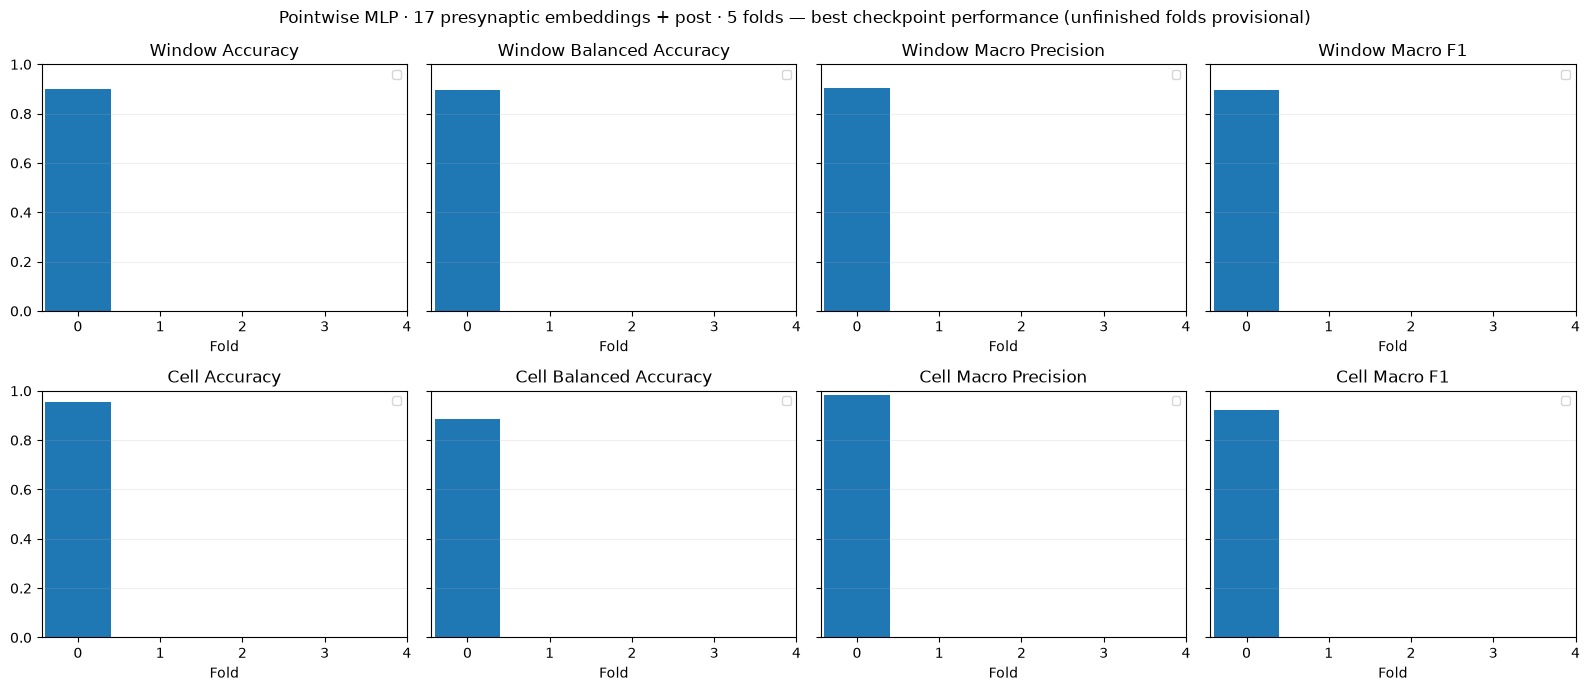

In [3]:
if payloads:
    fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharey=True)
    for ax, metric in zip(axes.flat, metric_columns):
        values = summary[metric]
        ax.bar(values.index, values, color=[COLORS[f] for f in values.index])
        if not completed.empty:
            mean = completed[metric].mean()
            ax.axhline(mean, color='black', linestyle='--', label=f'Completed mean {mean:.3f}')
        ax.set(title=metric.replace('_', ' ').title(), xlabel='Fold', xticks=list(FOLDS), ylim=(0, 1))
        ax.grid(axis='y', alpha=.2)
        ax.legend(fontsize=8)
    fig.suptitle(MODEL + ' — best checkpoint performance (unfinished folds provisional)')
    fig.tight_layout()
    plt.show()
else:
    print('Awaiting saved best-checkpoint metrics.')

## Training trajectories

Separate lines show each fold. Dots mark the saved best epoch on held-out F1 curves; these epochs can differ across folds.

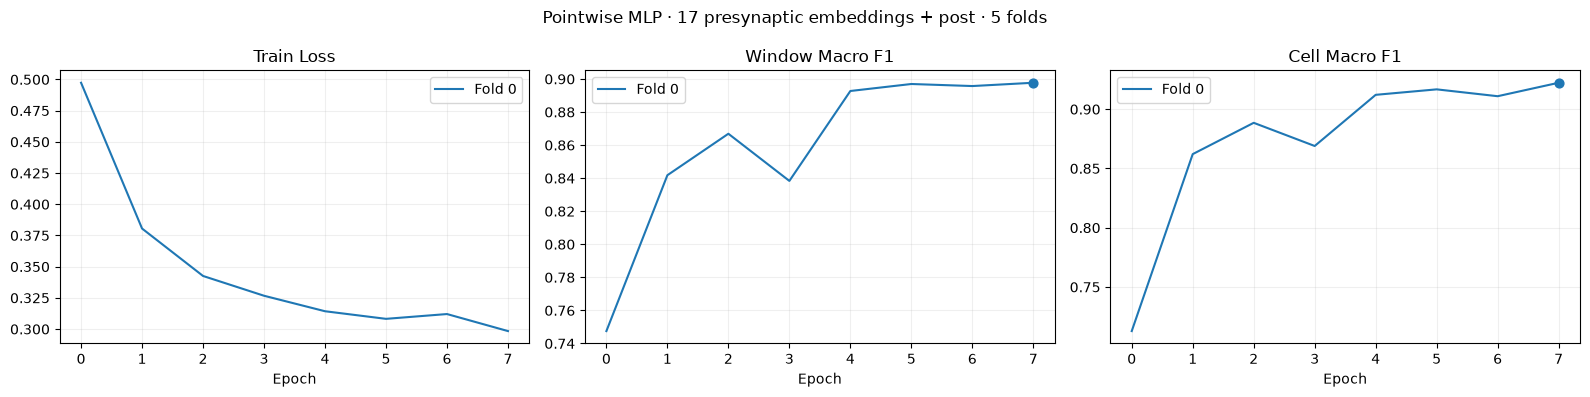

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric in zip(axes, ['train_loss', 'window_macro_f1', 'cell_macro_f1']):
    for fold, frame in curves.items():
        ax.plot(frame.epoch, frame[metric], color=COLORS[fold], label=f'Fold {fold}')
        if fold in payloads and metric != 'train_loss':
            best = frame[frame.epoch == payloads[fold]['best_epoch']]
            ax.scatter(best.epoch, best[metric], color=COLORS[fold], s=40, zorder=3)
    ax.set(title=metric.replace('_', ' ').title(), xlabel='Epoch')
    ax.grid(alpha=.2)
    if ax.lines:
        ax.legend()
fig.suptitle(MODEL)
fig.tight_layout()
plt.show()


## Per-class recall and support

Running folds show provisional best-checkpoint results. Per-class mean/std below includes all displayed folds; support counts explain rare-class variability.

Window recall by fold


fold,0,mean,std
BasketFam,0.9671,0.9671,NaN
Excitatory,0.9318,0.9318,NaN
nonBasketInhibitory,0.7879,0.7879,NaN


Window support by fold


,0
BasketFam,126617
Excitatory,155763
nonBasketInhibitory,124882


Cell recall by fold


fold,0,mean,std
BasketFam,1.0000,1.0000,NaN
Excitatory,1.0000,1.0000,NaN
nonBasketInhibitory,0.6596,0.6596,NaN


Cell support by fold


,0
BasketFam,33
Excitatory,279
nonBasketInhibitory,47


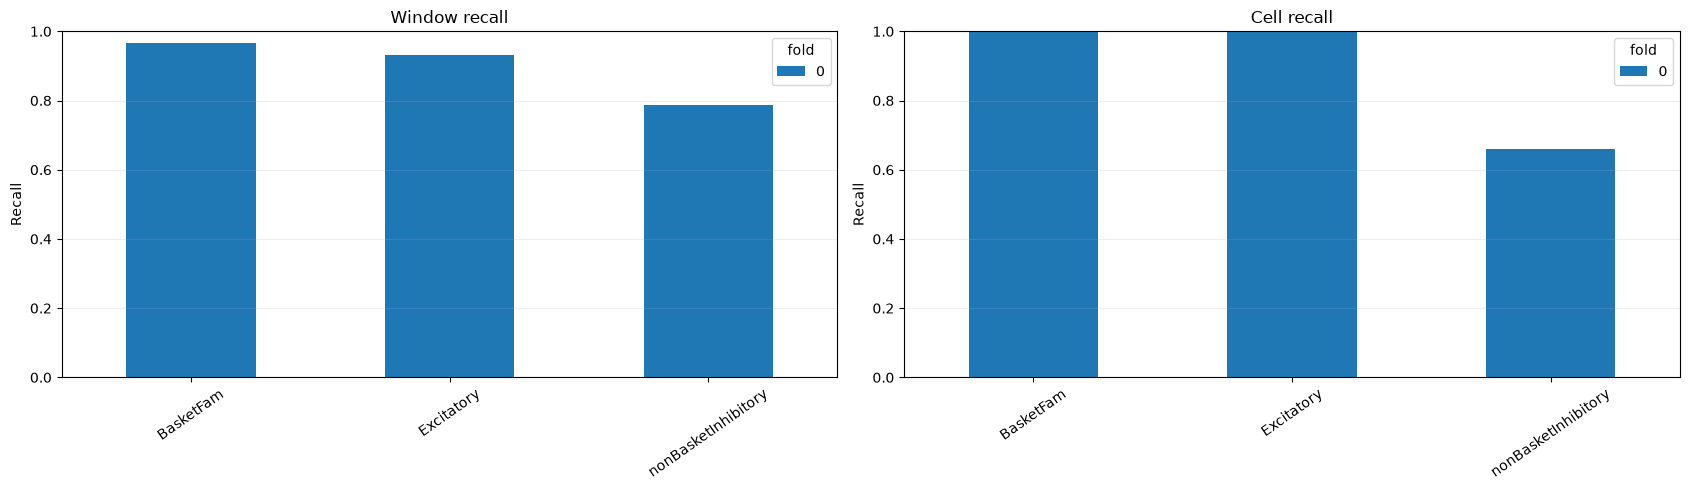

In [5]:
if payloads:
    classes = next(iter(payloads.values()))['classes']
    assert all(p['classes'] == classes for p in payloads.values()), 'Class ordering differs across folds'
    fig, axes = plt.subplots(1, 2, figsize=(17, 5))
    for ax, (scope, key) in zip(axes, [('window', 'window_test_metrics'), ('cell', 'test_metrics')]):
        recall = pd.DataFrame({fold: p[key]['per_class_recall'] for fold, p in payloads.items()}).reindex(classes)
        recall.columns.name = 'fold'
        support = pd.DataFrame({fold: np.asarray(p[key]['confusion_matrix']).sum(axis=1)
                                for fold, p in payloads.items()}, index=classes)
        print(f'{scope.title()} recall by fold')
        display(recall.assign(mean=recall.mean(axis=1), std=recall.std(axis=1, ddof=1)))
        print(f'{scope.title()} support by fold')
        display(support)
        recall.plot.bar(ax=ax, color=[COLORS[f] for f in recall.columns], rot=35)
        ax.set(title=f'{scope.title()} recall', ylabel='Recall', ylim=(0, 1))
        ax.grid(axis='y', alpha=.2)
    fig.tight_layout()
    plt.show()
else:
    print('Awaiting saved best-checkpoint metrics.')

## Confusion matrices across folds

Rows are true classes; columns are predicted classes. Each entry shows the row-normalized proportion and the raw count in parentheses. Running folds use provisional best-checkpoint results.

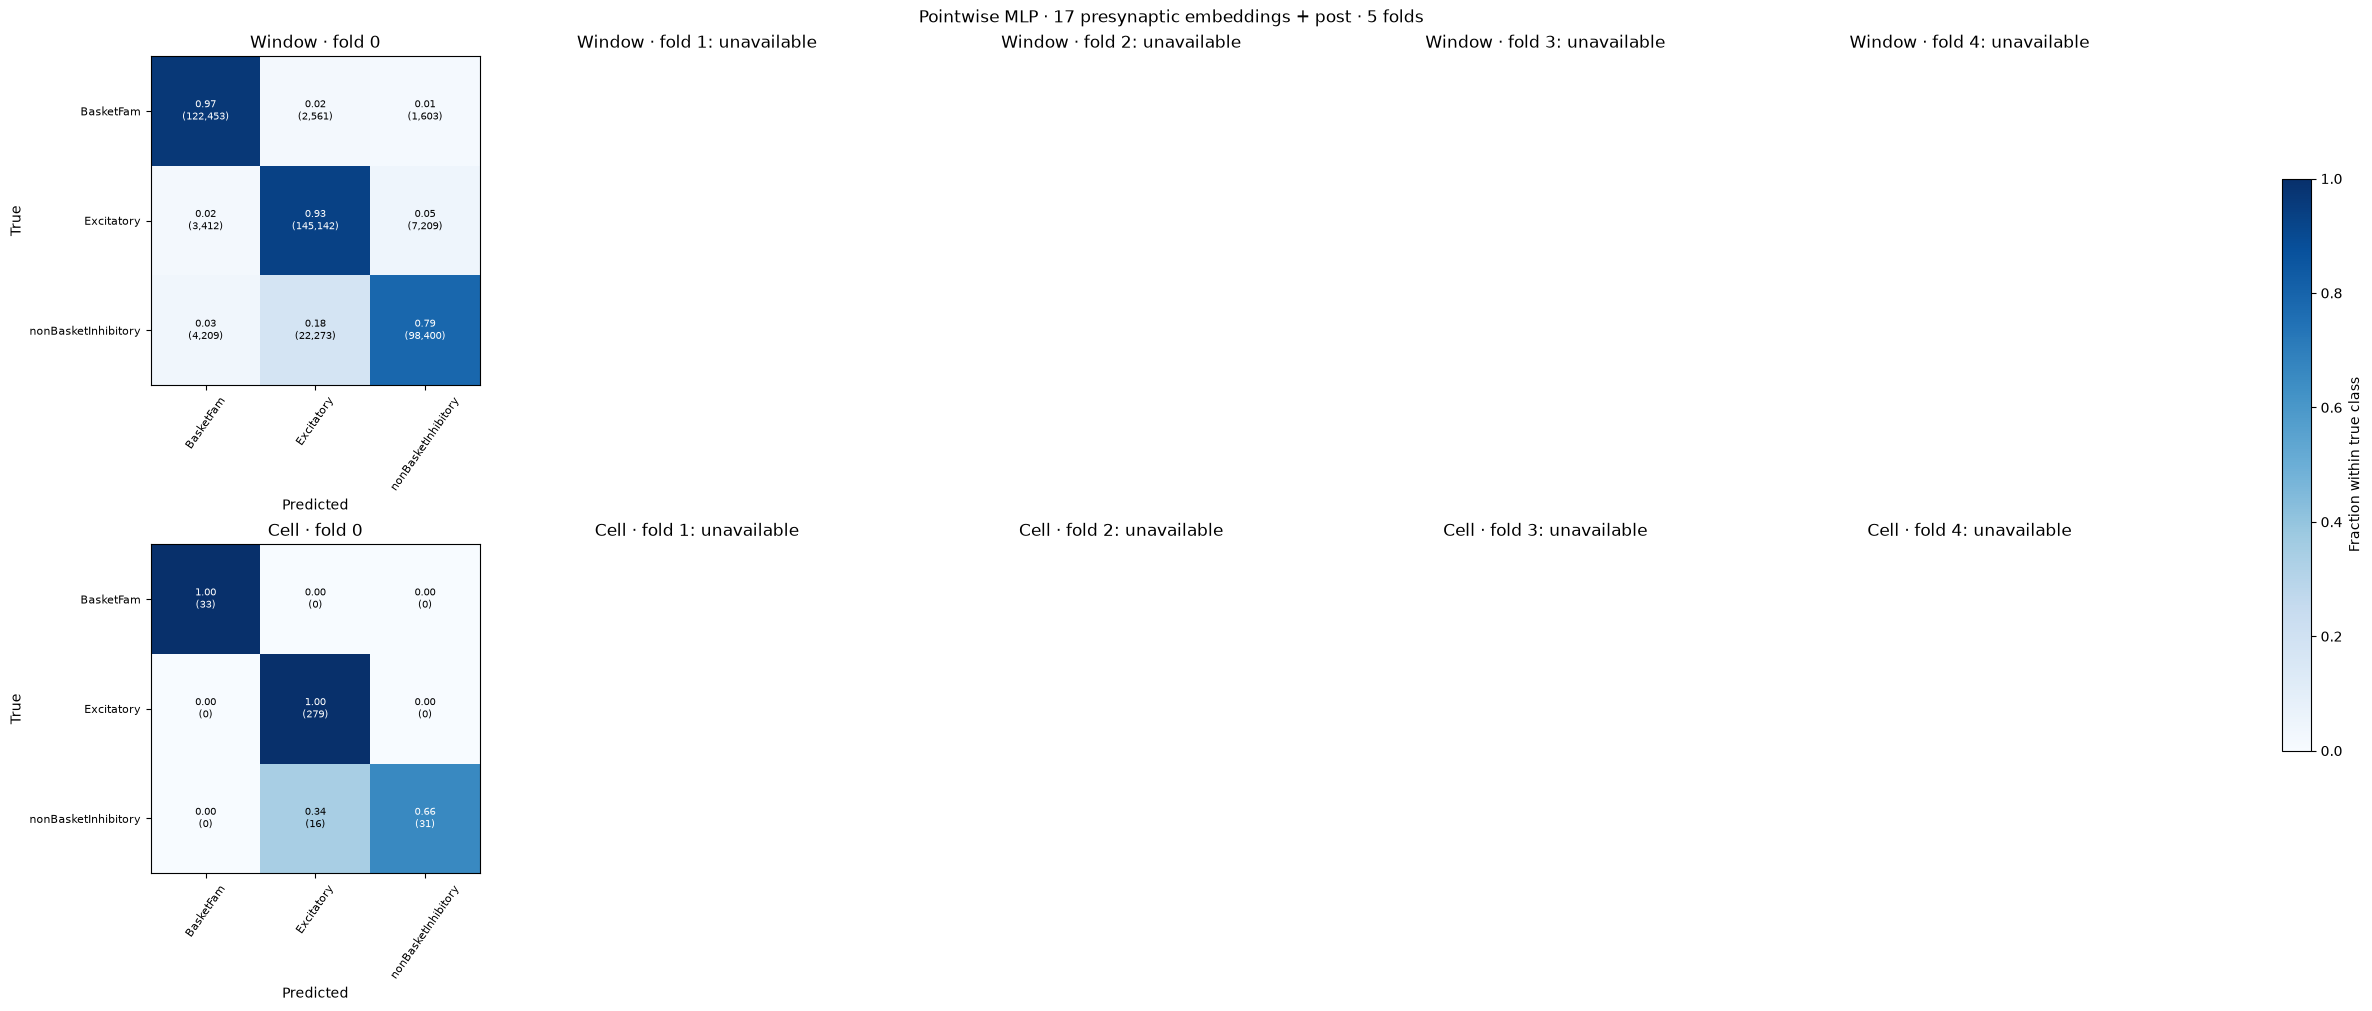

In [6]:
if payloads:
    fig, axes = plt.subplots(2, 5, figsize=(24, 10), layout='constrained')
    for row, (scope, key) in enumerate([('Window', 'window_test_metrics'), ('Cell', 'test_metrics')]):
        for fold in FOLDS:
            ax = axes[row, fold]
            if fold not in payloads:
                ax.set_title(f'{scope} · fold {fold}: unavailable')
                ax.axis('off')
                continue
            counts = np.asarray(payloads[fold][key]['confusion_matrix'])
            totals = counts.sum(axis=1, keepdims=True)
            normalized = np.divide(counts, totals, out=np.zeros_like(counts, dtype=float), where=totals != 0)
            im = ax.imshow(normalized, vmin=0, vmax=1, cmap='Blues')
            for (i, j), value in np.ndenumerate(normalized):
                ax.text(j, i, f'{value:.2f}\n({counts[i,j]:,})', ha='center', va='center', fontsize=7,
                        color='white' if value > .5 else 'black')
            ax.set(title=f'{scope} · fold {fold}', xticks=range(len(classes)), yticks=range(len(classes)),
                   xticklabels=classes, yticklabels=classes, xlabel='Predicted', ylabel='True')
            ax.tick_params(axis='x', rotation=55, labelsize=8)
            ax.tick_params(axis='y', labelsize=8)
    fig.colorbar(im, ax=axes, shrink=.7, label='Fraction within true class')
    fig.suptitle(MODEL)
    plt.show()
else:
    print('Awaiting saved best-checkpoint metrics.')